In [10]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('retail_sales_dataset.csv')

In [11]:
#initial inspection
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(1000, 9)
Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [12]:
#descriptive stats
df.describe()
df['Age'].mode()
df['Total Amount'].mode()


0    50
Name: Total Amount, dtype: int64

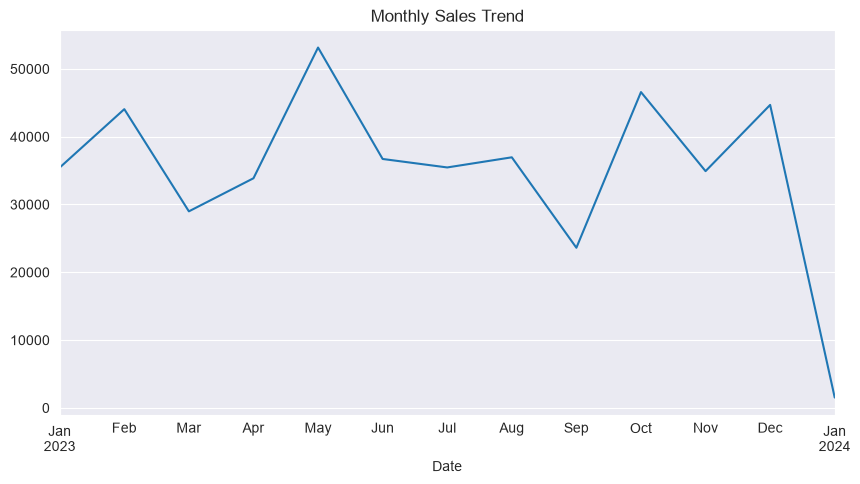

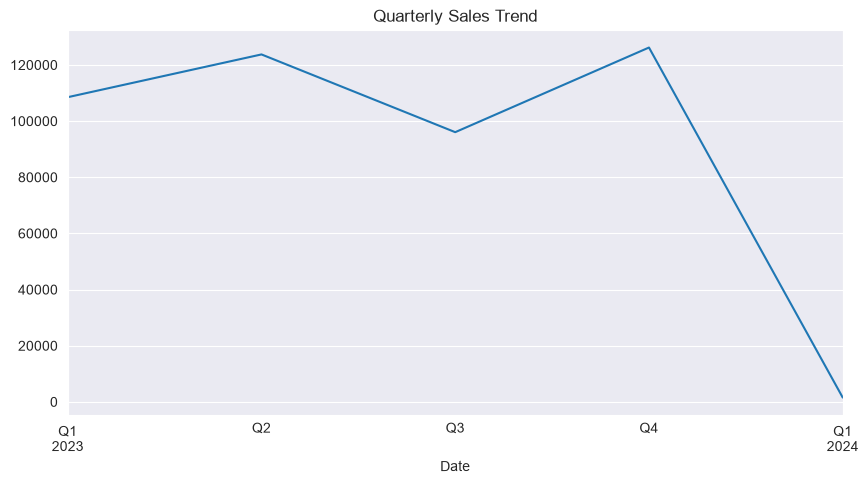

In [13]:
#Time series
df['Date'] = pd.to_datetime(df['Date'])
monthly = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()
monthly.plot(kind='line', figsize=(10,5), title='Monthly Sales Trend')
plt.show()

quarterly = df.groupby(df['Date'].dt.to_period('Q'))['Total Amount'].sum()
quarterly.plot(kind='line', figsize=(10,5), title='Quarterly Sales Trend')
plt.show()

MONTHLY SALES TREND CHART
Sales fluctuate month to month with no strong seasonal pattern. May had the highest sales around(53,000), while September was the lowest sales around(23,000). The sharp drop in Jan 2024 is due to incomplete data, as the dataset ends early that month, not because sales crashed.

QUARTERLY SALES TREND CHART
Sales were mostly consistent across Q1–Q4 of 2023, ranging roughly between 95,000 and 125,000, with Q4 being the strongest quarter. The drop shown in Q1 2024 reflects only partial data, not a real decline.

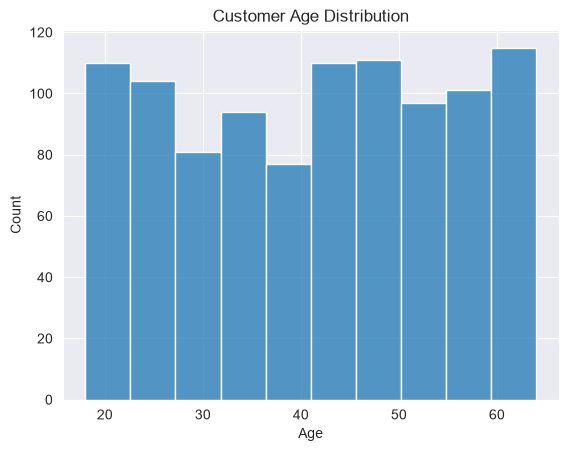

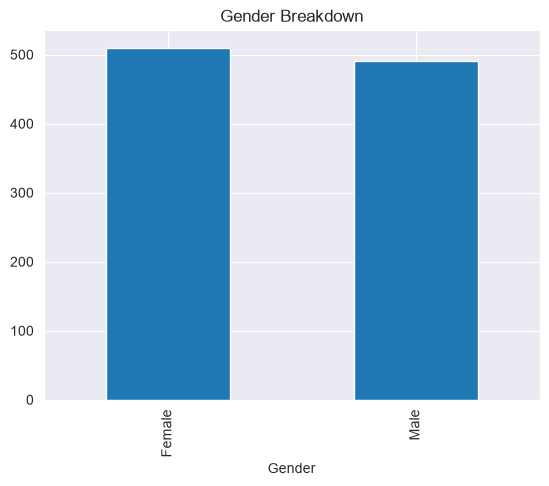

In [14]:
#demographics
sns.histplot(df['Age'], bins=10)
plt.title('Customer Age Distribution')
plt.show()

df['Gender'].value_counts().plot(kind='bar', title='Gender Breakdown')
plt.show()

AGE DISTRIBUTION
Customers are evenly spread across all age groups from 20–65, with no single age group standing out. Slight peaks appear in the 20–25 and 55–60 ranges.

GENDER BREAKDOWN
Almost equal split between male and female customers, with females slightly ahead (about 510 vs 490). Not a big enough gap to matter much.

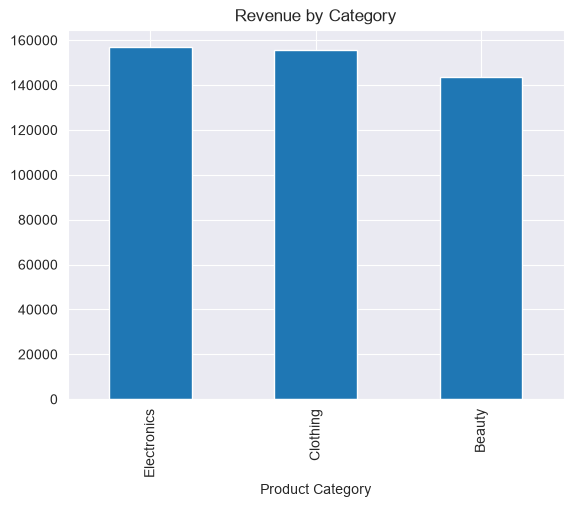

In [15]:
#product analysis
df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False).plot(kind='bar', title='Revenue by Category')
plt.show()

REVENUE BY CATEGORRY
Electronics shows the highest revenue (157,000), closely followed by Clothing (155,000). Beauty trails behind at ~143,000, but all three categories are doing okay, nothing is way behind

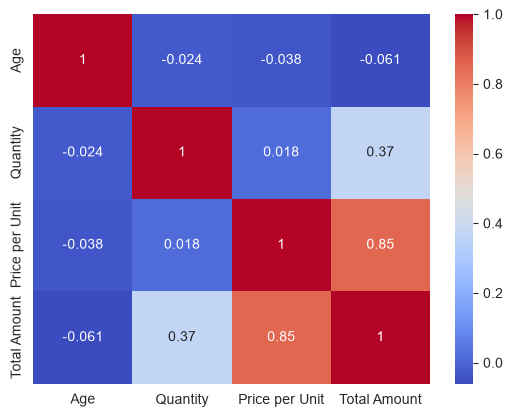

In [16]:
#correlation heatmap
sns.heatmap(df[['Age','Quantity','Price per Unit','Total Amount']].corr(), annot=True, cmap='coolwarm')
plt.show()

Total Amount mostly depends on Price per Unit (0.85 correlation) and a bit on Quantity (0.37). Age doesn't really affect how much someone spends.

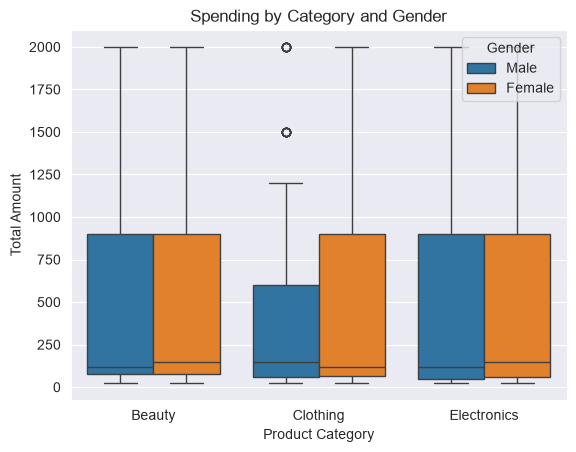

In [17]:
#bonus visuaalization
sns.boxplot(x='Product Category', y='Total Amount', hue='Gender', data=df)
plt.title('Spending by Category and Gender')
plt.show()

Clothing has the biggest difference between genders, men spend less than women in this category. Beauty and Electronics are about the same for both genders.

Conclusion & Recommendations

1. Electronics and Clothing bring in almost the same revenue, and both are ahead of Beauty. It makes sense to focus stock and ads on these two instead of splitting the budget equally across all three.

2. Sales go up the most in Q4 (Oct-Dec). Stores should stock up and run promotions before this period so they don't run out during the busiest months.

3. Men spend a lot less than women in the Clothing category specifically, while Beauty and Electronics are close between genders. This could mean the store should look into their Men's Clothing pricing or run offers targeted at male customers in that category.